# MockStream Path

In [1]:
"""
    TITLE   : Path of Mock Streams
    AUTHOR  : Nathaniel Starkman
    PROJECT : trackstream
""";

__author__ = 'Nathaniel Starkman'

<span style='font-size:30px;font-weight:650'>
    About
</span>

Running mock streams

<br><br>

- - - 


## Prepare

### Imports

In [18]:
from utilipy import ipython
ipython.run_imports(base=True, astropy=True, matplotlib=True,
                    galpy=True)

# BUILT-IN

# THIRD PARTY

import streamtools
from streamtools.df import streamspraydf

from galpy.df import streamdf
from galpy.actionAngle import actionAngleIsochroneApprox

# PROJECT-SPECIFIC

<br><br>

- - - 


## Online Example

In [33]:
o = Orbit([1.56148083,0.35081535,-1.15481504,0.88719443,-0.47713334,0.12019596])
lp = potential.LogarithmicHaloPotential(normalize=1.,q=0.9)

In [34]:
spdf = streamspraydf(
    2*10.**4.*u.Msun,
    progenitor=o,
    pot=lp,
    tdisrupt=4.5*u.Gyr
)
spdft = streamspraydf(
    2*10.**4.*u.Msun,
    progenitor=o,
    pot=lp,
    leading=False,
    tdisrupt=4.5*u.Gyr
)

In [35]:
np.random.seed(4)
RvR_noint, dt_noint = spdf.sample(
    n=100, returndt=True, integrate=False
)
RvRt_noint, dtt_noint = spdft.sample(
    n=100, returndt=True,integrate=False
)

In [36]:
np.random.seed(4)
RvR, dt = spdf.sample(n=100,returndt=True,integrate=True)
RvRt, dt = spdft.sample(n=100,returndt=True,integrate=True)

In [37]:
ts = np.linspace(0.,3.,301)
o.integrate(ts,lp)
of = o()
of.integrate(-ts,lp)

In [19]:
aAIA = actionAngleIsochroneApprox(b=0.8,pot=lp)
sigv = 0.365 #km/s
sdf = streamdf(
    sigv/220., progenitor=o(), pot=lp, aA=aAIA,
    leading=True, nTrackChunks=11, tdisrupt=4.5*u.Gyr
)

sdft= streamdf(
    sigv/220., progenitor=o(), pot=lp, aA=aAIA,
    leading=False, nTrackChunks=11, tdisrupt=4.5*u.Gyr
)

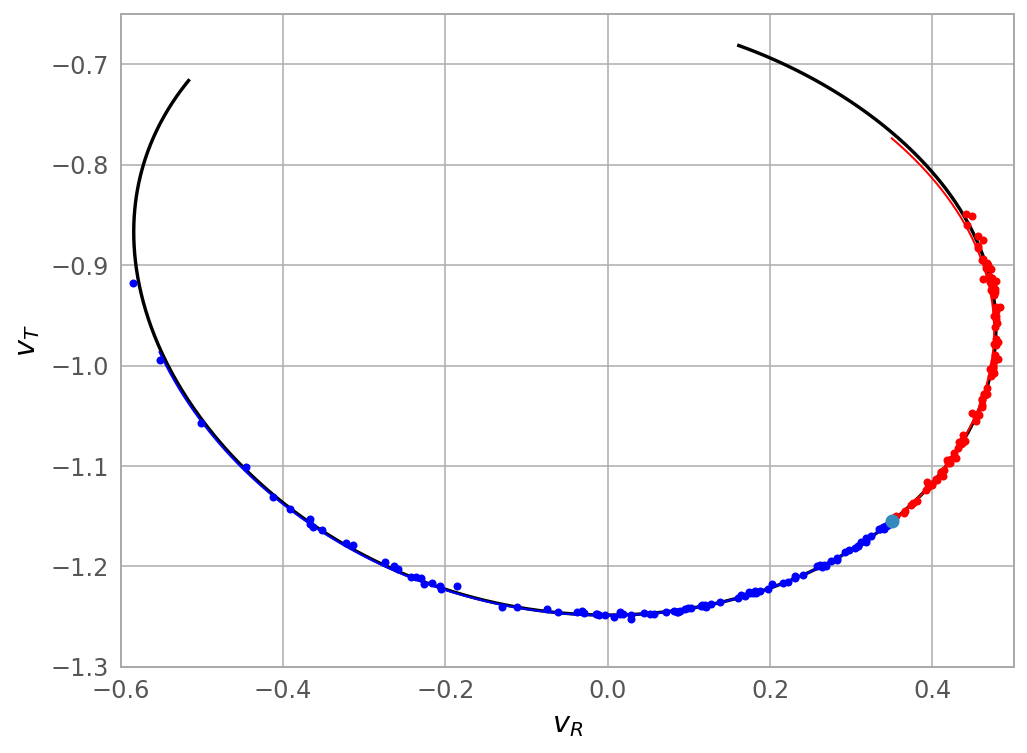

In [21]:
o.plot(d1='vR',d2='vT',color='k',xrange=[-0.6,0.5],yrange=[-1.3,-0.65])
of.plot(d1='vR',d2='vT',overplot=True,color='k')
plt.plot(RvR[1],RvR[2],'r.')
plt.plot(RvRt[1],RvRt[2],'b.')
sdf.plotTrack(d1='vR',d2='vT',interp=True,color='r',overplot=True,lw=1.)
sdft.plotTrack(d1='vR',d2='vT',interp=True,color='b',overplot=True,lw=1.)
plt.plot(o.vR(),o.vT(),'o');

<br><br>

- - - 


## Pal5

In [94]:
from trackstream import examples


In [95]:
pal5_obs = examples.get_stream_data().cartesian
pal5_clr = np.linspace(0, 256, len(pal5_obs))

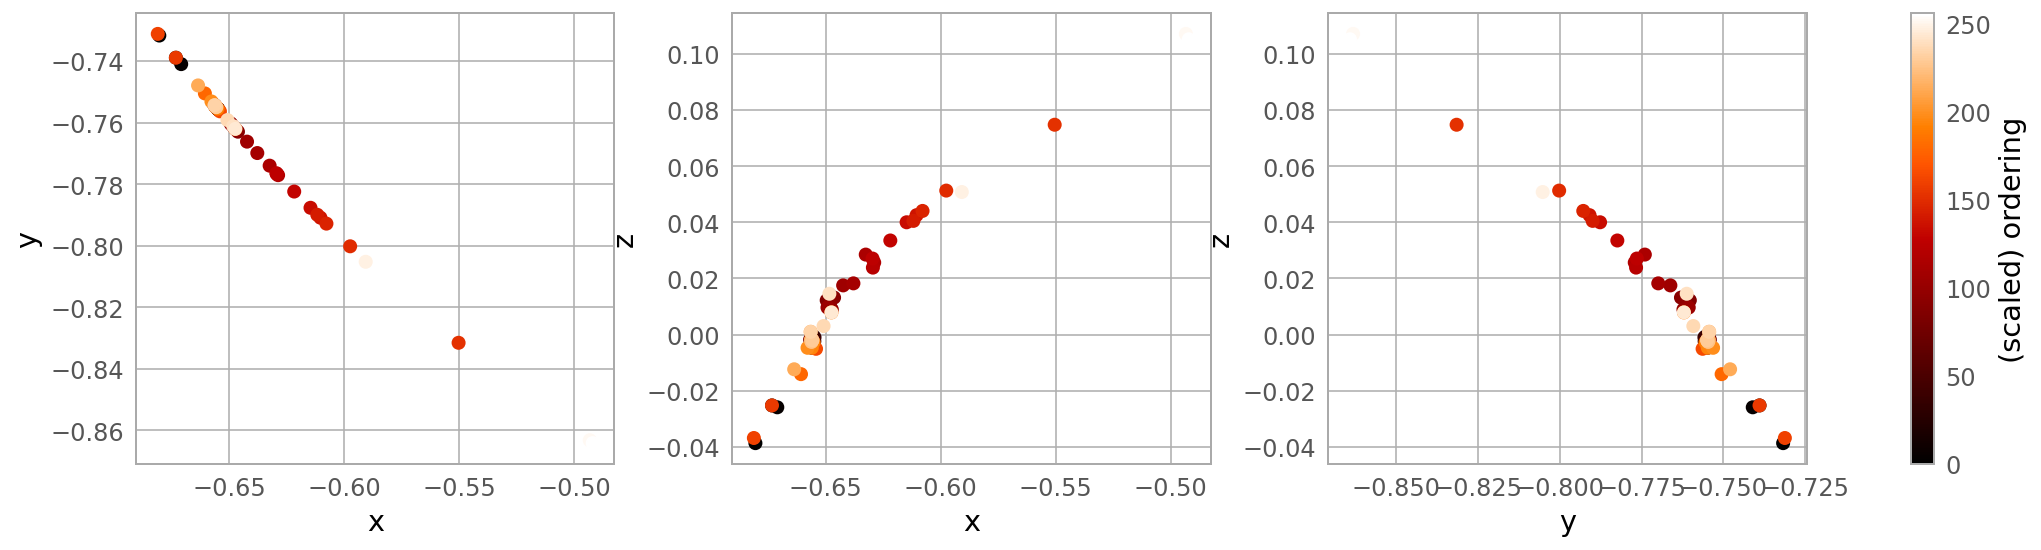

In [96]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))

axs[0].scatter(pal5_obs.x, pal5_obs.y, c=pal5_clr)
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")

axs[1].scatter(pal5_obs.x, pal5_obs.z, c=pal5_clr)
axs[1].set_xlabel("x")
axs[1].set_ylabel("z")

scat = axs[2].scatter(pal5_obs.y, pal5_obs.z, c=pal5_clr)
axs[2].set_xlabel("y")
axs[2].set_ylabel("z")

plt.tight_layout()
cbar = plt.colorbar(scat, ax=axs)
cbar.ax.set_ylabel("(scaled) ordering")
plt.show();

In [172]:
# Pal 5 Orbit
# [ra,dec,d,mu_ra, mu_dec,vlos]
o = Orbit(vxvv=[229.022, -0.112, 22.9, -2.736, -2.646, -58.60], radec=True)
o.turn_physical_off()
pot = potential.MWPotential2014

In [173]:
spdfl = streamspraydf(
    3e4*u.Msun,
    progenitor=o,
    pot=pot,
    leading=True,
    tdisrupt=4.5*u.Gyr
)
spdft = streamspraydf(
    3e4*u.Msun,
    progenitor=o,
    pot=pot,
    leading=False,
    tdisrupt=4.5*u.Gyr
)

In [174]:
np.random.seed(4)

RvRl_noint, dtl_noint = spdfl.sample(
    n=100, returndt=True, integrate=False
)
RvRt_noint, dtt_noint = spdft.sample(
    n=100, returndt=True,integrate=False
)

In [177]:
np.random.seed(4)
RvRl, dt = spdfl.sample(n=100,returndt=True,integrate=True)
RvRt, dt = spdft.sample(n=100,returndt=True,integrate=True)

In [178]:
ts = np.linspace(0.,3.,301)
o.integrate(ts, pot)

of = o()
of.integrate(-ts, pot)

In [213]:
def galpy_RvR_to_dict(cyl):
    rho = u.Quantity(cyl[0], unit=u.kpc)
    return {
        "rho": rho,
        "phi": u.Quantity(cyl[5], unit=u.deg),
        "z": u.Quantity(cyl[3], unit=u.kpc),
        "d_rho": u.Quantity(cyl[1], unit=u.km/u.s),
        "d_phi": (u.Quantity(cyl[2], unit=u.km/u.s) / rho).to(u.mas/u.yr, equivalencies=u.dimensionless_angles()),
        "d_z": u.Quantity(cyl[4], unit=u.km/u.s),
    }

rvrl = galpy_RvR_to_dict(RvRl)
differentials = coord.CylindricalDifferential(**{k: v for k, v in rvrl.items() if k.startswith("d_")})
rep = coord.CylindricalRepresentation(**{k: v for k, v in rvrl.items() if not k.startswith("d_")}, differentials=differential)
c = coord.Galactocentric(rep)

c = c.transform_to(coord.ICRS)

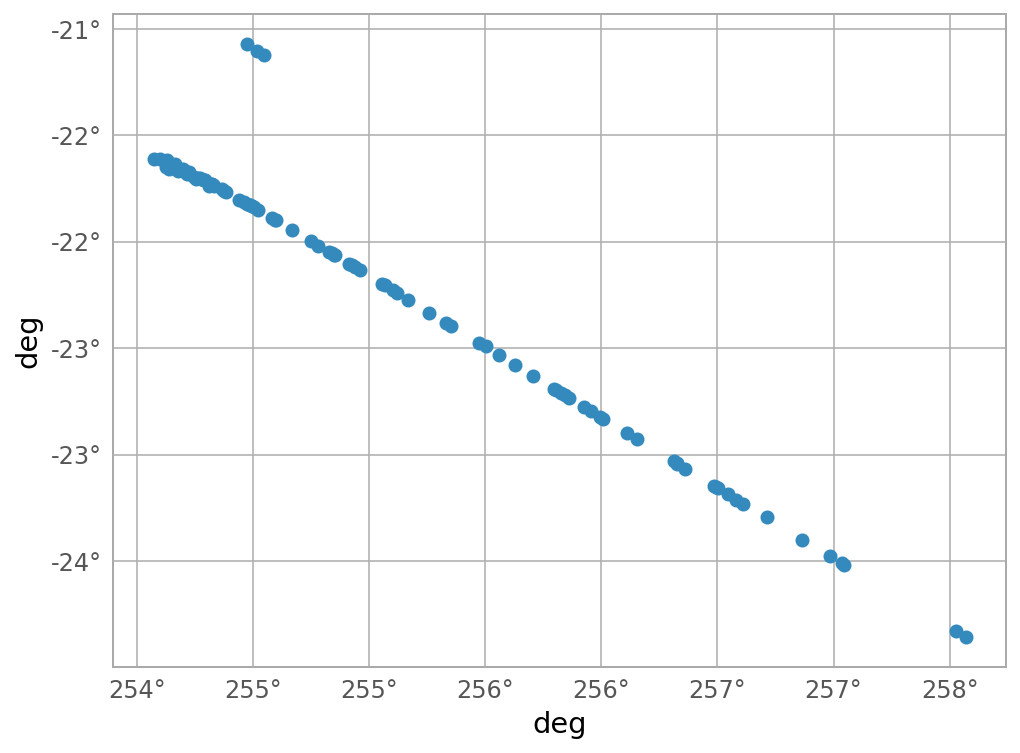

In [215]:
plt.scatter(c.ra, c.dec)

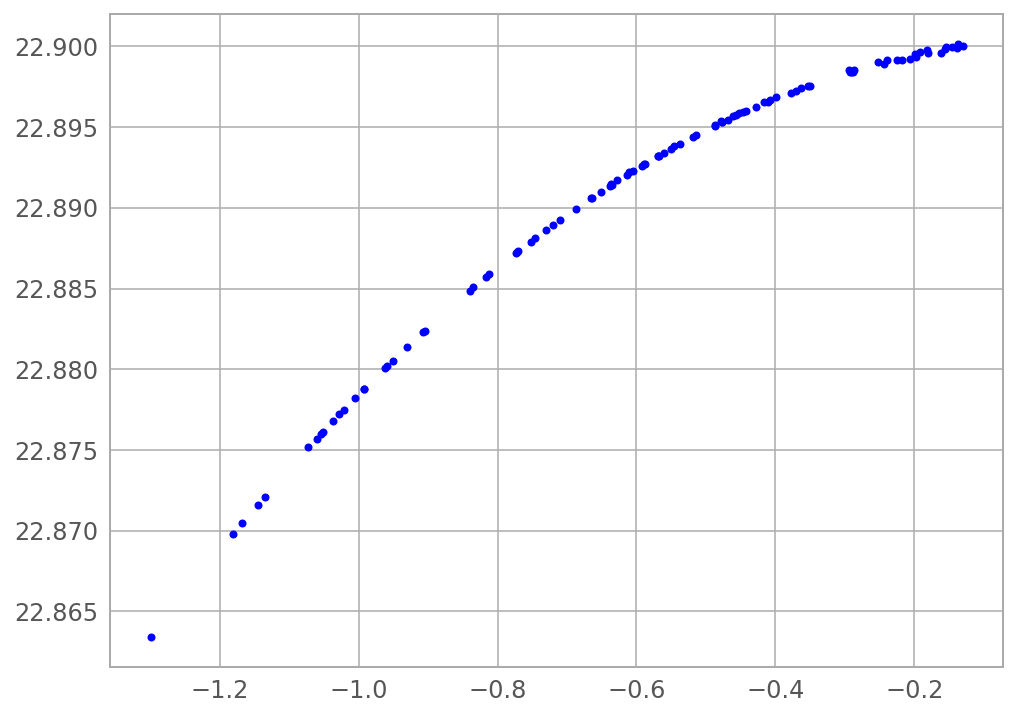

In [158]:
plt.plot(RvRt[1],RvRt[2],'b.')

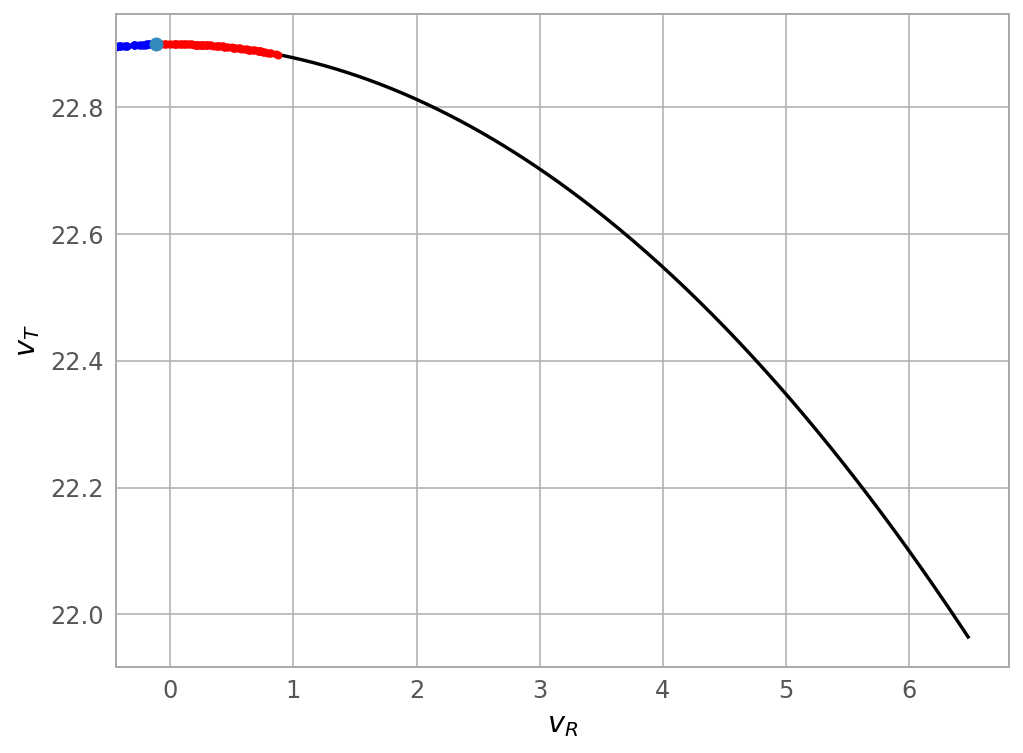

In [159]:
o.plot(d1='vR',d2='vT',color='k')
of.plot(d1='vR',d2='vT',overplot=True,color='k')
plt.plot(RvRl[1],RvRl[2],'r.')
plt.plot(RvRt[1],RvRt[2],'b.')
sdf.plotTrack(d1='vR',d2='vT',interp=True,color='r',overplot=True,lw=1.)
sdft.plotTrack(d1='vR',d2='vT',interp=True,color='b',overplot=True,lw=1.)
plt.plot(o.vR(),o.vT(),'o');

<br><br>

- - - 

<span style='font-size:40px;font-weight:650'>
    END
</span>